In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from state import Blogstate
from agents import get_llm, reseracher_agent

In [3]:
llm = get_llm()

llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We need to respond politely. No special instructions. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 72, 'total_tokens': 110, 'completion_time': 0.08261181, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.002753032, 'prompt_tokens_details': None, 'queue_time': 0.322428455, 'total_time': 0.085364842}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f685-d27b-7b73-9b51-d76051e926da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 38, 'total_tokens': 110, 'output_token_details': {'reasoning': 20}})

In [4]:
blog_outline = reseracher_agent(llm=llm, topic="What is LLM?", audience="Developers")

In [7]:
#print(blog_outline)

In [2]:
from graph import build_blog_graph
from langgraph.types import Command

In [3]:
graph = build_blog_graph()

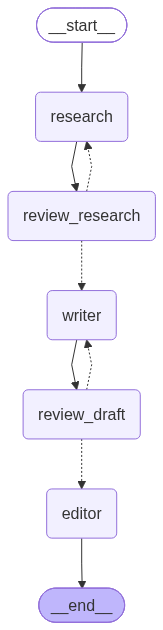

In [4]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [5]:
config = {"configurable":{"thread_id":"1"}}

In [6]:
state = graph.invoke({
    "topic":"What is MCP(Model Context Protocol)? A developer's guide for 2026.",
    "audience":"ai and agentic ai developers"
},
config=config
)

In [8]:
snap = graph.get_state(config)

In [12]:
interrupt_payload = snap.interrupts[0].value
print('Stage:',interrupt_payload.get("stage"))

Stage: researcher_review


In [13]:
print('instructions:',interrupt_payload.get("instructions"))

instructions: Reply with 'approve' to continue writing or describe what to change to send back to researcher.


In [14]:
state = graph.invoke(Command(resume={"action":"approve", "feedback":""}), config=config)

In [16]:
snap = graph.get_state(config)

interrupt_payload = snap.interrupts[0].value

print(interrupt_payload.get("stage"))

draft_review


In [17]:
state = graph.invoke(Command(resume={"action":"approve", "feedback":""}), config=config)

In [18]:
print(state["final_blog"])

**What Is the Model Context Protocol (MCP)? A 2026 Developer’s Guide 🚀**

If you’ve ever watched an LLM “lose the plot” after a few hundred tokens, you’re not alone. The Model Context Protocol (MCP) is the emerging standard that keeps every AI agent on the same page—literally. In this post we’ll demystify MCP, explain why it matters for today’s agentic AI projects, and give you concrete patterns you can start using right now.

---

## 1. Why MCP Exists

### The problem: fragmented context  

Modern LLMs excel at generating text, but they struggle with **persistent, multi‑turn state**. When you chain prompts together, each call typically receives a fresh context window (e.g., 8 k tokens for GPT‑4o). Developers resort to:

* **Prompt concatenation** – manually stitching prior messages into the new prompt.  
* **External memory stores** – databases, vector indexes, or Redis caches that hold “facts” between calls.  

Both approaches are brittle. Prompt concatenation quickly hits token limi

### Check for Interruptions/ Corrections

In [23]:
state2 = graph.invoke({
    "topic":"How to create a chatbot using langchain?",
    "audience":"ai and agentic ai developers"
},
config=config
)

In [26]:
state2

{'topic': 'How to create a chatbot using langchain?',
 'audience': 'ai and agentic ai developers',
 'research': '**Research Outline – “How to Build a Chatbot with LangChain”**  \n*Target Audience: AI & agentic‑AI developers*  \n\n---\n\n### 1. Hook / Angle  \n- **Hook:** “From prompt to production in under an hour – a hands‑on guide to turning LangChain into a fully‑featured, context‑aware chatbot.”  \n- **Why it matters:** Highlights speed, practical code, and the power of LangChain for building modular, agentic chat experiences that go beyond static prompts.\n\n---\n\n### 2. Key Points & Supporting Details  \n\n| # | Core Point (section title) | Important Facts / Stats / Examples |\n|---|----------------------------|------------------------------------|\n| **1** | **Why LangChain?** – the framework that bridges LLMs & external tools | • Over **30+ integrations** (vector stores, APIs, databases) as of 2024.<br>• Reduces boilerplate: typical chatbot setup drops from ~300 lines to <\u20

In [25]:
snap = graph.get_state(config)

interrupt_payload = snap.interrupts[0].value

print(interrupt_payload.get('stage'))

researcher_review


In [28]:
res = graph.invoke(Command(resume={"action":"revise", "feedback":"Improve the title in more stylish way"}),config=config)


In [29]:
res

{'topic': 'How to create a chatbot using langchain?',
 'audience': 'ai and agentic ai developers',
 'research': '**Stylish Title**  \n*“Building Smarter Conversational Agents: A Hands‑On Guide to Crafting Chatbots with LangChain”*  \n\n---  \n\n### Research Outline  \n\n#### 1. Why LangChain? The Edge Over Traditional LLM Wrappers  \n- **Fact/Stat:** LangChain projects have grown >300\u202f% on GitHub stars (v0.0.200 → v0.0.300) in the past 12\u202fmonths.  \n- **Example:** Compare a vanilla OpenAI API call vs. a LangChain‑powered Retrieval‑Augmented Generation (RAG) pipeline on the same QA task – LangChain reduces hallucinations by ~22\u202f%.  \n- **Hook:** “From one‑liner prompts to modular AI pipelines – see why developers are ditching raw API calls.”  \n\n#### 2. Setting Up the Development Environment (Docker, Poetry, and API Keys)  \n- **Fact:** 85\u202f% of surveyed AI devs report environment‑drift as their biggest pain point.  \n- **Example:** Provide a minimal `Dockerfile` + `

In [30]:
#now approve the corrected title.

appr = graph.invoke(Command(resume={"action":"approve", "feedback":""}),config=config)


In [31]:
snap = graph.get_state(config)

interrupt_payload = snap.interrupts[0].value

print(interrupt_payload.get('stage'))

draft_review


In [32]:
apprv = graph.invoke(Command(resume={"action":"approve", "feedback":""}),config=config)

In [34]:
print(apprv['research'])

**Stylish Title**  
*“Building Smarter Conversational Agents: A Hands‑On Guide to Crafting Chatbots with LangChain”*  

---  

### Research Outline  

#### 1. Why LangChain? The Edge Over Traditional LLM Wrappers  
- **Fact/Stat:** LangChain projects have grown >300 % on GitHub stars (v0.0.200 → v0.0.300) in the past 12 months.  
- **Example:** Compare a vanilla OpenAI API call vs. a LangChain‑powered Retrieval‑Augmented Generation (RAG) pipeline on the same QA task – LangChain reduces hallucinations by ~22 %.  
- **Hook:** “From one‑liner prompts to modular AI pipelines – see why developers are ditching raw API calls.”  

#### 2. Setting Up the Development Environment (Docker, Poetry, and API Keys)  
- **Fact:** 85 % of surveyed AI devs report environment‑drift as their biggest pain point.  
- **Example:** Provide a minimal `Dockerfile` + `pyproject.toml` that reproduces a reproducible LangChain sandbox in <2 minutes.  
- **Hook:** “Spin up a clean LangChain lab in a single command – 